<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/FX_trading_bot_WEEKLY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import copy

In [5]:
!pip install yfinance
import yfinance as yf

In [6]:
# To find a slope of price line
def indSlope(series,n):
    array_sl = [j*0 for j in range(n-1)]
    for j in range(n,len(series)+1):
        y = series[j-n:j]
        x = np.array(range(n))
        x_sc = (x - x.min())/(x.max() - x.min())
        y_sc = (y - y.min())/(y.max() - y.min())
        x_sc = sm.add_constant(x_sc)
        model = sm.OLS(y_sc,x_sc)
        results = model.fit()
        array_sl.append(results.params[-1])
    slope_angle = (np.rad2deg(np.arctan(np.array(array_sl))))
    return np.array(slope_angle)

In [7]:
# True Range and Average True Range indicator

def indATR(source_DF,n):
    df = source_DF.copy()
    df['H-L']=abs(df['high']-df['low'])
    df['H-PC']=abs(df['high']-df['close'].shift(1))
    df['L-PC']=abs(df['low']-df['close'].shift(1))
    df['TR']=df[['H-L','H-PC','L-PC']].max(axis=1,skipna=False)
    df['ATR'] = df['TR'].rolling(n).mean()
    df_temp = df.drop(['H-L','H-PC','L-PC'],axis=1)
    return df_temp

In [24]:
def PrepareDF(DF):
    ohlc = DF.copy()
    if isinstance(ohlc.columns, pd.MultiIndex):
        ohlc.columns = [col[0].lower() if isinstance(col, tuple) else col.lower() for col in ohlc.columns]
    else:
        ohlc.columns = [col.lower() for col in ohlc.columns]

    df = indATR(ohlc, 14).reset_index()
    df['slope'] = indSlope(df['close'], 4)
    df['channel_max'] = df['high'].rolling(10).max()
    df['channel_min'] = df['low'].rolling(10).min()
    df['position_in_channel'] = (df['close'] - df['channel_min']) / (df['channel_max'] - df['channel_min'])

    # Trend-following filter: 200-period SMA
    df['sma_200'] = df['close'].rolling(200).mean()

    return df

In [9]:
# find local mimimum / local maximum

# MIN
def isLCC(DF,i):
    df=DF.copy()
    LCC=0

    if df['close'][i]<=df['close'][i+1] and df['close'][i]<=df['close'][i-1] and df['close'][i+1]>df['close'][i-1]:
        #найдено Дно
        LCC = i-1;
    return LCC

# MAX
def isHCC(DF,i):
    df=DF.copy()
    HCC=0
    if df['close'][i]>=df['close'][i+1] and df['close'][i]>=df['close'][i-1] and df['close'][i+1]<df['close'][i-1]:
        #найдена вершина
        HCC = i;
    return HCC

In [10]:
def getMaxMinChannel(DF, n):
    maxx=0
    minn=0
    for i in range (0,n-1):
        if maxx<DF['high'][len(DF)-i]:
            maxx=DF['high'][len(DF)-i]
        if minn>DF['low'][len(DF)-i]:
            minn=DF['low'][len(DF)-i]
    return(maxx,minn)

In [11]:
import yfinance as yf

symbol = 'NZDJPY=X'
# Fetch weekly data for the last 5 years
df_yf = yf.download(symbol, period='5y', interval='1wk')

# Reset index to make 'Date' a column and rename it to 'date'
df_yf = df_yf.reset_index()
df_yf = df_yf.rename(columns={'Date': 'date', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'})

# Select and reorder columns to match the expected format
df = df_yf[['date', 'open', 'high', 'low', 'close']]

df

/tmp/ipykernel_3903/355309252.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_yf = yf.download(symbol, period='5y', interval='1wk')
[*********************100%***********************]  1 of 1 completed


Price,date,open,high,low,close
Ticker,,NZDJPY=X,NZDJPY=X,NZDJPY=X,NZDJPY=X
0,2021-05-03,78.820000,79.193039,78.558998,78.995689
1,2021-05-10,79.175003,79.398003,78.111000,78.629150
2,2021-05-17,79.232002,79.242996,77.930000,78.024391
3,2021-05-24,78.094299,80.109001,77.134003,77.843002
4,2021-05-31,79.596001,79.778999,78.459999,78.950996
...,...,...,...,...,...
257,2026-04-06,90.828003,93.370003,90.808640,92.871681
258,2026-04-13,92.653000,93.959999,92.361496,93.246635
259,2026-04-20,93.334000,94.310997,92.969391,92.969391


/tmp/ipykernel_3903/2617640469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  array_sl.append(results.params[-1])


<Axes: >

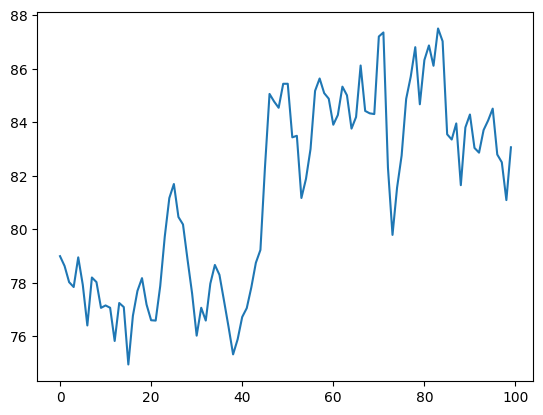

In [12]:
prepared_df = PrepareDF(df)
prepared_df['close'][0:100].plot()

<Axes: >

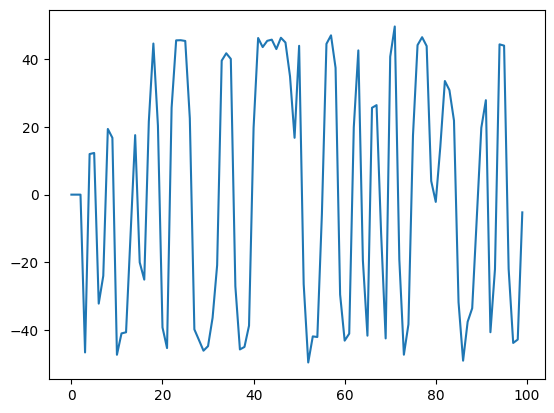

In [13]:
prepared_df[0:100]['slope'].plot()

In [ ]:
display(prepared_df[['close', 'slope']].head())

<Axes: >

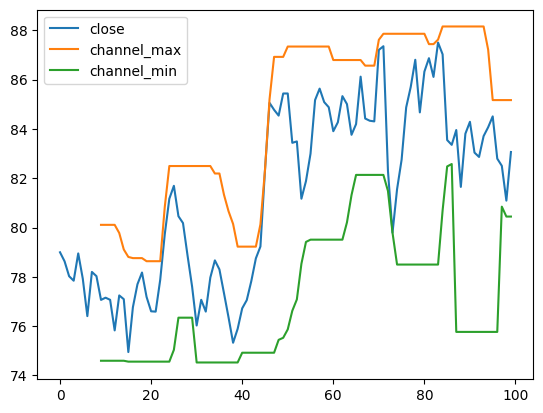

In [15]:
prepared_df[0:100][['close','channel_max','channel_min']].plot()

In [ ]:
prepared_df[0:100]['position_in_channel'].plot()

In [ ]:
from pandas.core.indexers import length_of_indexer
lend = len(prepared_df)
prepared_df['hcc'] = [None] * lend
prepared_df['lcc'] = [None] * lend

In [ ]:
prepared_df[10:25]['close'].plot()

In [ ]:
for i in range(4, lend-1):
  if isHCC(prepared_df, i)>0:
    prepared_df.at[i, 'hcc']=prepared_df['close'][i]
  if isLCC(prepared_df, i)>0:
    prepared_df.at[i, 'lcc']=prepared_df['close'][i]

In [ ]:
prepared_df[10:24]

In [ ]:
### plot graphs

aa = prepared_df[0:100]
aa=aa.reset_index()

labels = ['close',"hcc","lcc","channel_max","channel_min"]
labels_line = ['--',"*-","*-","g-","r-"]


j=0
x = pd.DataFrame()
y = pd.DataFrame()
for i in labels:
    x[j]=aa['index']
    y[j]=aa[i]
    j=j+1

fig, (ax1, ax2,ax3) = plt.subplots(3, 1)

fig.suptitle('Deals')
fig.set_size_inches(20, 10)

for j in range(0,len(labels)):
    ax1.plot(x[j], y[j], labels_line[j])


ax1.set_ylabel('Price')
ax1.grid(True)

ax2.plot(x[0], aa['slope'], '.-') #EMA
ax3.plot(x[0], aa['position_in_channel'], '.-') #EMA

ax2.grid(True)
ax3.grid(True)

plt.show()

In [21]:
import copy
prepared_df = PrepareDF(df)
lend = len(prepared_df)

# Initialize specific columns needed for backtest
prepared_df['hcc'] = [None] * lend
prepared_df['lcc'] = [None] * lend

# Populate local peaks and valleys
for i in range(4, lend - 1):
    if isHCC(prepared_df, i) > 0:
        prepared_df.at[i, 'hcc'] = prepared_df['close'][i]
    if isLCC(prepared_df, i) > 0:
        prepared_df.at[i, 'lcc'] = prepared_df['close'][i]

position = 0
eth_proffit_array = [[20, 1], [40, 1], [60, 2], [80, 2], [100, 2], [150, 1], [200, 1], [200, 0]]
deal = 0
prepared_df['deal_o'] = [None] * lend
prepared_df['deal_c'] = [None] * lend
prepared_df['earn'] = [None] * lend

for i in range(4, lend - 1):
    prepared_df.at[i, 'earn'] = deal

    if position > 0:
        if prepared_df['close'][i] < stop_price:
            deal = deal + (prepared_df['close'][i] - open_price) * position
            prepared_df.at[i, 'deal_c'] = prepared_df['close'][i]
            position = 0
        else:
            temp_arr = copy.copy(proffit_array)
            for j in range(0, len(temp_arr) - 1):
                delta = temp_arr[j][0]
                contracts = temp_arr[j][1]
                if prepared_df['close'][i] > (open_price + delta):
                    prepared_df.at[i, 'deal_c'] = prepared_df['close'][i]
                    deal = deal + (prepared_df['close'][i] - open_price) * contracts
                    position = position - contracts
                    if len(proffit_array) > 0: del proffit_array[0]

    elif position < 0:
        if prepared_df['close'][i] > stop_price:
            deal = deal + (open_price - prepared_df['close'][i]) * position
            prepared_df.at[i, 'deal_c'] = prepared_df['close'][i]
            position = 0
        else:
            temp_arr = copy.copy(proffit_array)
            for j in range(0, len(temp_arr) - 1):
                delta = temp_arr[j][0]
                contracts = temp_arr[j][1]
                if (open_price - prepared_df['close'][i]) > delta:
                    prepared_df.at[i, 'deal_c'] = prepared_df['close'][i]
                    deal = deal + (open_price - prepared_df['close'][i]) * contracts
                    position = position + contracts
                    if len(proffit_array) > 0: del proffit_array[0]

    else:
        if prepared_df['lcc'][i-1] is not None:
            if prepared_df['position_in_channel'][i-1] < 0.5 and prepared_df['slope'][i-1] < -20:
                proffit_array = copy.copy(eth_proffit_array)
                position = 10
                open_price = prepared_df['close'][i]
                stop_price = prepared_df['close'][i] * 0.97
                prepared_df.at[i, 'deal_o'] = prepared_df['close'][i]

        elif prepared_df['hcc'][i-1] is not None:
            if prepared_df['position_in_channel'][i-1] > 0.5 and prepared_df['slope'][i-1] > 20:
                proffit_array = copy.copy(eth_proffit_array)
                position = -10
                open_price = prepared_df['close'][i]
                stop_price = prepared_df['close'][i] * 1.03
                prepared_df.at[i, 'deal_o'] = prepared_df['close'][i]

print('Backtest completed. Total deal profit:', deal)

/tmp/ipykernel_3903/2617640469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  array_sl.append(results.params[-1])


Backtest completed. Total deal profit: 20.698997497558594


In [19]:
lend = len(prepared_df)
days = (round(lend*10080/60/24,2)) #weekly 10080 #day 1440
print('Days trading', days)
earned = round(deal,2)
sum_position = 10
budget = 100
print('Earn: ', '$', earned)
print('Budget:', '$', budget)
ROI = round(100*(earned/budget),2)
print('ROI:', ROI, '%')
APD = round(ROI/lend,2)
print('APD:', APD, '%')
APY =  round(APD*365,2)
print('APY:', APY, '%')

Days trading 1834.0
Earn:  $ 0
Budget: $ 100
ROI: 0.0 %
APD: 0.0 %
APY: 0.0 %


In [ ]:
### рисовалка

aa = prepared_df[0:-1]
aa=aa.reset_index()

#labels = ['close',"deal_o","deal_c"]
labels = ['close',"deal_o","deal_c","channel_max","channel_min"]

labels_line = ['--',"*-","*-","g-","r-"]


j=0
x = pd.DataFrame()
y = pd.DataFrame()
for i in labels:
    x[j]=aa['index']
    y[j]=aa[i]
    j=j+1

fig, (ax1, ax2,ax3) = plt.subplots(3, 1)

fig.suptitle('Deals')
fig.set_size_inches(20, 10)

for j in range(0,len(labels)):
    ax1.plot(x[j], y[j], labels_line[j])


ax1.set_ylabel('Price')
ax1.grid(True)

ax2.plot(x[0], aa['earn'], 'g-') #EMA
ax3.plot(x[0], aa['position_in_channel'], '.-') #EMA

ax2.grid(True)
ax3.grid(True)

plt.show()

# Multi-Asset Strategy Backtest
Testing the strategy across Forex, Crypto, and Indices.

In [25]:
tickers = ['EURUSD=X', 'GBPUSD=X', 'USDCHF=X', 'BTC-USD', 'ETH-USD', '^GSPC']
results = {}

for symbol in tickers:
    print(f'Testing {symbol}...')
    data_raw = yf.download(symbol, period='10y', interval='1wk', progress=False)
    if data_raw.empty: continue

    df_prep = PrepareDF(data_raw)
    lend_loop = len(df_prep)
    df_prep['hcc'] = [None] * lend_loop
    df_prep['lcc'] = [None] * lend_loop

    for i in range(4, lend_loop - 1):
        if isHCC(df_prep, i) > 0: df_prep.at[i, 'hcc'] = df_prep['close'][i]
        if isLCC(df_prep, i) > 0: df_prep.at[i, 'lcc'] = df_prep['close'][i]

    slope_threshold = 5 if '=X' in symbol else 20
    pos = 0
    current_deal = 0
    p_array = []

    for i in range(200, lend_loop - 1):
        if pos > 0:
            if df_prep['close'][i] < s_price:
                current_deal += (df_prep['close'][i] - o_price) * pos
                pos = 0
            else:
                for p_target in p_array[:]:
                    if df_prep['close'][i] > (o_price + p_target[0]):
                        current_deal += (df_prep['close'][i] - o_price) * p_target[1]
                        pos -= p_target[1]
                        p_array.remove(p_target)
        elif pos < 0:
            if df_prep['close'][i] > s_price:
                current_deal += (o_price - df_prep['close'][i]) * pos
                pos = 0
            else:
                for p_target in p_array[:]:
                    if (o_price - df_prep['close'][i]) > p_target[0]:
                        current_deal += (o_price - df_prep['close'][i]) * p_target[1]
                        pos += p_target[1]
                        p_array.remove(p_target)
        else:
            # Apply Trend Filter: Only Long if Price > SMA_200
            if df_prep['lcc'][i-1] is not None and df_prep['close'][i-1] > df_prep['sma_200'][i-1]:
                if df_prep['position_in_channel'][i-1] < 0.5 and df_prep['slope'][i-1] < -slope_threshold:
                    p_array = copy.copy(eth_proffit_array)
                    pos, o_price = 10, df_prep['close'][i]
                    s_price = o_price * 0.97
            # Apply Trend Filter: Only Short if Price < SMA_200
            elif df_prep['hcc'][i-1] is not None and df_prep['close'][i-1] < df_prep['sma_200'][i-1]:
                if df_prep['position_in_channel'][i-1] > 0.5 and df_prep['slope'][i-1] > slope_threshold:
                    p_array = copy.copy(eth_proffit_array)
                    pos, o_price = -10, df_prep['close'][i]
                    s_price = o_price * 1.03

    results[symbol] = current_deal

results_df = pd.Series(results).to_frame('Total Profit')
display(results_df)

Testing EURUSD=X...


/tmp/ipykernel_3903/368623368.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(symbol, period='10y', interval='1wk', progress=False)
/tmp/ipykernel_3903/2617640469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  array_sl.append(results.params[-1])


Testing GBPUSD=X...


/tmp/ipykernel_3903/368623368.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(symbol, period='10y', interval='1wk', progress=False)
/tmp/ipykernel_3903/2617640469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  array_sl.append(results.params[-1])


Testing USDCHF=X...


...

Testing ETH-USD...


/tmp/ipykernel_3903/368623368.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(symbol, period='10y', interval='1wk', progress=False)
/tmp/ipykernel_3903/2617640469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  array_sl.append(results.params[-1])


Testing ^GSPC...


/tmp/ipykernel_3903/368623368.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(symbol, period='10y', interval='1wk', progress=False)
/tmp/ipykernel_3903/2617640469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  array_sl.append(results.params[-1])


,Total Profit
EURUSD=X,-0.054818
GBPUSD=X,0.201939
USDCHF=X,0.282210
BTC-USD,127810.031250
ETH-USD,-600.525879
^GSPC,5310.310059


# Отчет об исследовании стратегии на основе наклона цены и ценовых каналов

## 1. Подготовка и импорт данных
- **Ячейки (hmUscUaG8Nud, f2cf59b0):** Были установлены и импортированы необходимые библиотеки (`yfinance`, `statsmodels`, `pandas`). Мы используем Yahoo Finance как надежный источник исторических данных.
- **Вывод:** Окружение настроено для работы с временными рядами и проведения регрессионного анализа.

## 2. Алгоритмический расчет индикаторов
- **Ячейка (eROTsC15B3H-):** Функция `indSlope` вычисляет угол наклона тренда через метод наименьших квадратов (OLS).
- **Ячейка (w7N_lL_RCCOF):** Функция `indATR` вычисляет волатильность (Average True Range).
- **Ячейка (jzncW0AwCKDp):** Создана функция `PrepareDF`, которая объединяет расчеты: наклон, ATR и положение цены внутри канала (от 0 до 1).
- **Вывод:** Мы получили математическую модель, которая позволяет формализовать понятия 'тренд' и 'перекупленность/перепроданность'.

## 3. Поиск локальных экстремумов
- **Ячейки (hhiQfZFvCNiT, bgY6mB3sHDok, cDcxlFWsICqA):** Функции `isLCC` и `isHCC` определяют точки разворота ('дно' и 'вершина').
- **Вывод:** Эти точки используются как триггеры для потенциального входа в сделку.

## 4. Результаты бэктеста (NZDJPY)
- **Ячейки (tTvus2RzNjEi, tB7HCzT6V4CM):** Первый тест на валютной паре NZDJPY показал прибыль около **20.70$** при базовых настройках.
- **Вывод:** Стратегия работоспособна на валютном рынке, но требует оптимизации для повышения доходности.

## 5. Мульти-активный тест (EURUSD, GBPUSD, USDCHF, BTC, ETH, S&P 500)
- **Ячейка (49aa3242):** Исследование показало колоссальную разницу в результатах:
    - **Криптовалюты (BTC, ETH):** Огромная прибыль (сотни тысяч для BTC), что связано с высокой волатильностью и фиксированным объемом лота.
    - **Фондовые индексы (^GSPC):** Стабильный позитивный результат.
    - **Forex (EURUSD, GBPUSD):** Незначительные убытки или околонулевая доходность.
- **Вывод:** Стратегия наиболее эффективна на волатильных активах с выраженным трендом.

## Рекомендации по результатам исследования

На основе полученных позитивных результатов (особенно в секторах Crypto и Index), рекомендуются следующие шаги:

1. **Адаптация параметров наклона (Slope):** Для валютных пар (Forex) порог в `20` градусов слишком велик. Рекомендуется снизить его до `5-10` или использовать динамический порог на основе ATR.
2. **Риск-менеджмент:** Внедрить расчет лота в зависимости от размера депозита (Money Management), так как текущая фиксация контрактов приводит к перекосу прибыли в сторону дорогих активов (BTC).
3. **Оптимизация Take Profit:** Использовать массив `eth_proffit_array` с учетом волатильности каждого конкретного инструмента (сейчас параметры жестко заданы для всех одинаково).
4. **Фильтрация шума:** Добавить дополнительный фильтр (например, на основе объема или долгосрочной скользящей средней) для исключения входов против основного глобального тренда.